In [7]:
import h5py
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams["mathtext.fontset"] = "cm"
plt.rcParams["font.family"] = "serif"



In [8]:
# base_path = "/users/lyang4/borah_scratch/multi_wave/N3600/shuffle/Github_code/selection_bias_wu22/bias_data_Ycyl/"
data_path = "data/"
fname     = data_path + "wu22_eq8_Ycyl_selected_profiles_proj300_nscy_linear_with_mm_mPDF.h5"

selector = "Y500c_true"
survey_idx = 2   # 0: ACT_DR6, 1: ACT_DR6_Legacy, 2: SPT_SZ, 3: SPTpol_500d

with h5py.File(fname, "r") as f:
    g = f[f"selection_sets/{selector}/meta"]

    M_spt_sz = g["M_centers"][survey_idx]
    pdf_sel_spt_sz = g["pdf_mass"][survey_idx]
    pdf_mm_spt_sz = g["pdf_massmatched"][survey_idx]

    M_sptpol = g["M_centers"][3]
    pdf_sel_sptpol = g["pdf_mass"][3]
    pdf_mm_sptpol = g["pdf_massmatched"][3]

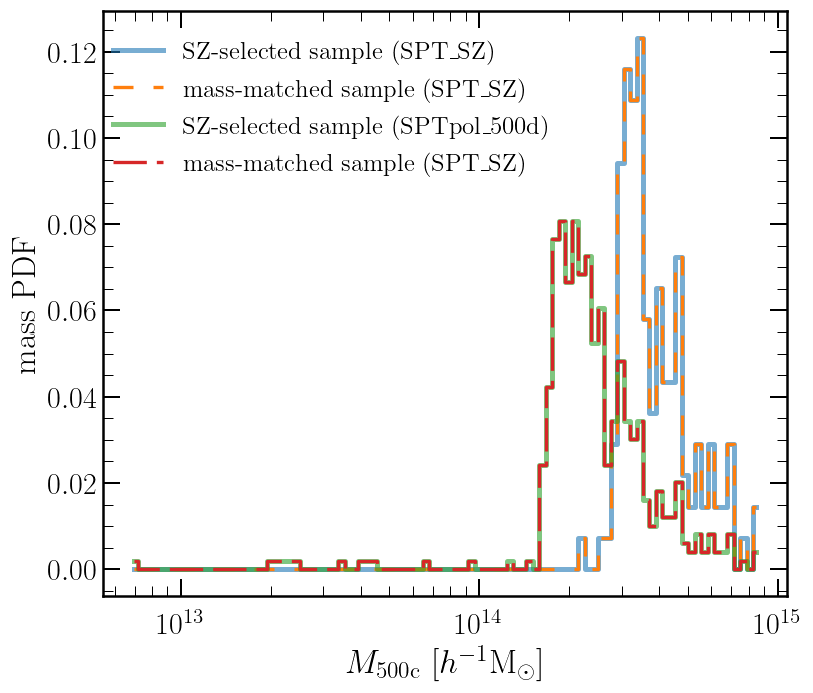

In [9]:

fig, ax = plt.subplots(1, 1, figsize=(7, 6), dpi=120)#, sharey=True)

plt.step(M_spt_sz, pdf_sel_spt_sz, where="mid", lw=3, alpha=0.6,
         label="SZ-selected sample (SPT_SZ)")
plt.step(M_spt_sz, pdf_mm_spt_sz, where="mid", linestyle="--", dashes=(6,6), 
         label=r"mass-matched sample (SPT_SZ)")

plt.step(M_sptpol, pdf_sel_sptpol, where="mid", lw=3, alpha=0.6,
         label=r"SZ-selected sample (SPTpol_500d)")
plt.step(M_sptpol, pdf_mm_sptpol, where="mid", linestyle="--", dashes=(10,3), 
         label=r"mass-matched sample (SPT_SZ)")

# plt.title()
plt.xscale("log")
plt.xlabel(r"$M_{\rm 500c}$ [$h^{-1} \rm M_\odot$]", fontsize=20)
plt.ylabel("mass PDF", fontsize=20)

ax.tick_params(axis='both', which='both', labelsize=18, length=6, width=.6, 
               top=True, right=True, direction='in')
ax.tick_params(axis='both', which='major', length=10, width=1.2, 
               top=True, right=True, direction='in')
ax.minorticks_on()
plt.legend(frameon=False, fontsize=15, loc=[0.0,0.7])
plt.savefig('../plots/Ycyl_mass.pdf')
plt.show()


In [10]:
#For the Ycyl-selected output:
survey_idx = 2
with h5py.File(fname, "r") as f:
    g = f["selection_sets/Y500c_true/results/Sigma"]
    y = f["selection_sets/Y500c_true/results/cy_true"]

    rp = g["rp"][:]

    # Wu22 method (iii): mass-PDF weighting
    sig_bias_pdf_spt_sz = g["bias_sim"][survey_idx]
    sig_bias_pdf_err_spt_sz = g["bias_sim_err"][survey_idx]

    # Wu22 method (ii): random mass-matched sample
    sig_bias_mm_spt_sz = g["bias_sim_mm"][survey_idx]
    sig_bias_mm_err_spt_sz = g["bias_sim_mm_err"][survey_idx]

    # Wu22 method (iii): mass-PDF weighting
    cy_bias_pdf_spt_sz = y["bias_sim"][survey_idx]
    cy_bias_pdf_err_spt_sz = y["bias_sim_err"][survey_idx]

    # Wu22 method (ii): random mass-matched sample
    cy_bias_mm_spt_sz = y["bias_sim_mm"][survey_idx]
    cy_bias_mm_err_spt_sz = y["bias_sim_mm_err"][survey_idx]


#     rp = g["rp"][:]
    ###############################################################
    survey_idx = 3
    # Wu22 method (iii): mass-PDF weighting
    sig_bias_pdf_sptpol = g["bias_sim"][survey_idx]
    sig_bias_pdf_err_sptpol = g["bias_sim_err"][survey_idx]

    # Wu22 method (ii): random mass-matched sample
    sig_bias_mm_sptpol = g["bias_sim_mm"][survey_idx]
    sig_bias_mm_err_sptpol = g["bias_sim_mm_err"][survey_idx]

    # Wu22 method (iii): mass-PDF weighting
    cy_bias_pdf_sptpol = y["bias_sim"][survey_idx]
    cy_bias_pdf_err_sptpol = y["bias_sim_err"][survey_idx]

    # Wu22 method (ii): random mass-matched sample
    cy_bias_mm_sptpol = y["bias_sim_mm"][survey_idx]
    cy_bias_mm_err_sptpol = y["bias_sim_mm_err"][survey_idx]

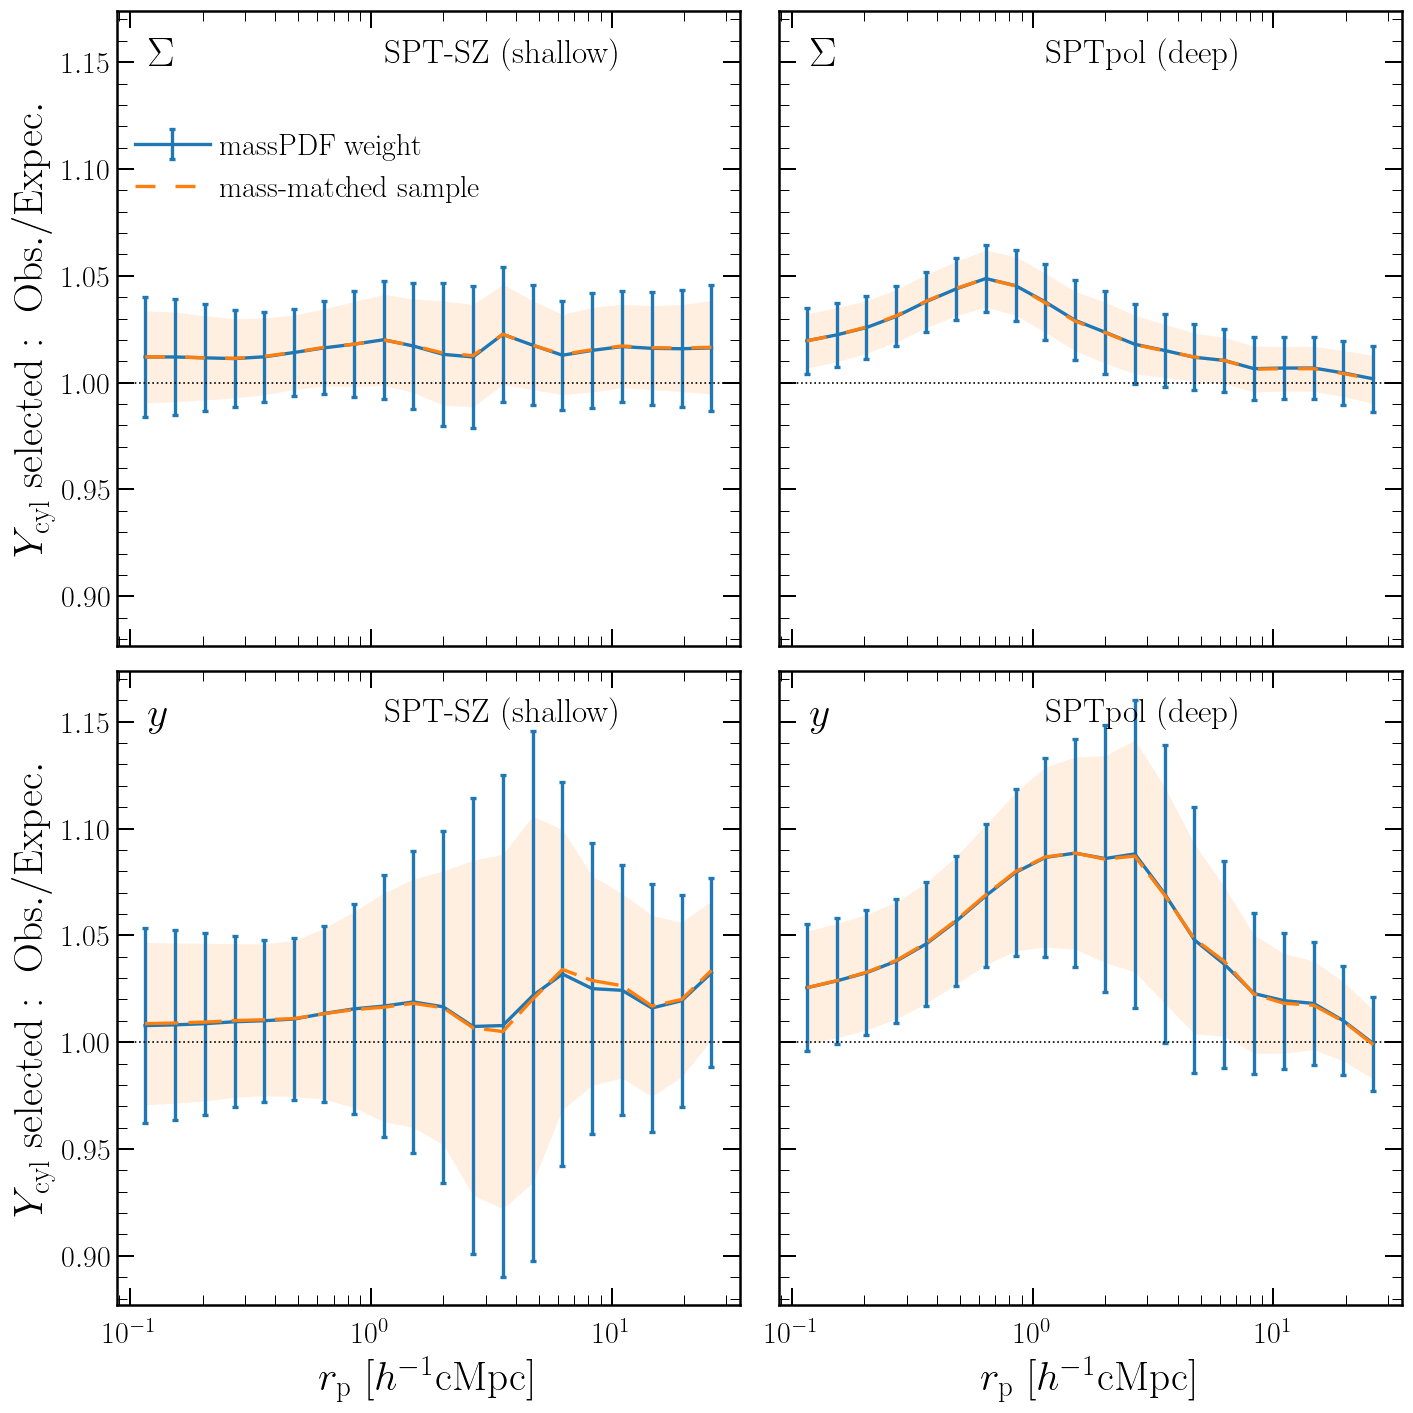

In [11]:
# ------------------------------------------------------------
# Helper functions
# ------------------------------------------------------------
def style_ax(ax, xlabel=False, ylabel=None):
    ax.set_xscale("log")
    ax.axhline(1, color="black", linestyle=":", alpha=1, linewidth=1)

    ax.tick_params(
        axis='both', which='both',
        labelsize=18, length=6, width=.6,
        top=True, right=True, direction='in'
    )
    ax.tick_params(
        axis='both', which='major',
        length=10, width=1.2,
        top=True, right=True, direction='in'
    )
    ax.minorticks_on()

    if xlabel:
        ax.set_xlabel(r"$r_{\rm p}~[h^{-1}\mathrm{cMpc}]$", fontsize=25)

    if ylabel is not None:
        ax.set_ylabel(ylabel, fontsize=25)


def plot_bias_panel(ax, rp, bias_pdf, bias_pdf_err, bias_mm, bias_mm_err,
                    quantity_label=None, survey_label=None,
                    show_legend=False, mm_dashes=(6, 6)):
    # Wu22 method (iii): massPDF weight
    ax.errorbar(
        rp, bias_pdf,
        yerr=bias_pdf_err,
        elinewidth=2, capsize=2, capthick=2,
        label="massPDF weight"
    )

    # Wu22 method (ii): mass-matched sample
    line = ax.errorbar(
        rp, bias_mm,
        yerr=None,
        ls="--", dashes=mm_dashes,
        label="mass-matched sample"
    )[0]

    ax.fill_between(
        rp,
        bias_mm - bias_mm_err,
        bias_mm + bias_mm_err,
        color=line.get_color(), alpha=0.12, lw=0
    )

    # quantity label inside panel
    if quantity_label is not None:
        ax.text(
            0.05, 0.96,
            quantity_label,
            transform=ax.transAxes,
            ha='left', va='top', fontsize=25
        )

    # survey label inside panel
    if survey_label is not None:
        ax.text(
            0.43, 0.96,
            survey_label,
            transform=ax.transAxes,
            ha='left', va='top', fontsize=20
        )

    if show_legend:
        ax.legend(
            frameon=False, fontsize=18, loc=[0.01, 0.68],
            handlelength=2.5, handletextpad=0.3,
        )


# ------------------------------------------------------------
# Make figure: 2 rows x 2 cols
# left column  = SPT-SZ
# right column = SPTpol
# top row      = Sigma
# bottom row   = y
# ------------------------------------------------------------
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(
    2, 2, figsize=(12, 12), dpi=120, sharex=True, sharey=True #'row'
)

# ------------------------------------------------------------
# Top-left: Sigma, SPT-SZ
# ------------------------------------------------------------
plot_bias_panel(
    ax1,
    rp,
    sig_bias_pdf_spt_sz,
    sig_bias_pdf_err_spt_sz,
    sig_bias_mm_spt_sz,
    sig_bias_mm_err_spt_sz,
    quantity_label=r"$\Sigma$",
    survey_label=r"SPT-SZ (shallow)",
    show_legend=True,
    mm_dashes=(6, 6),
)

# ------------------------------------------------------------
# Top-right: Sigma, SPTpol
# ------------------------------------------------------------
plot_bias_panel(
    ax2,
    rp,
    sig_bias_pdf_sptpol,
    sig_bias_pdf_err_sptpol,
    sig_bias_mm_sptpol,
    sig_bias_mm_err_sptpol,
    quantity_label=r"$\Sigma$",
    survey_label=r"SPTpol (deep)",
    show_legend=False,
    mm_dashes=(6, 6),
)

# ------------------------------------------------------------
# Bottom-left: y, SPT-SZ
# ------------------------------------------------------------
plot_bias_panel(
    ax3,
    rp,
    cy_bias_pdf_spt_sz,
    cy_bias_pdf_err_spt_sz,
    cy_bias_mm_spt_sz,
    cy_bias_mm_err_spt_sz,
    quantity_label=r"$y$",
    survey_label=r"SPT-SZ (shallow)",
    show_legend=False,
    mm_dashes=(10, 3),
)

# ------------------------------------------------------------
# Bottom-right: y, SPTpol
# ------------------------------------------------------------
plot_bias_panel(
    ax4,
    rp,
    cy_bias_pdf_sptpol,
    cy_bias_pdf_err_sptpol,
    cy_bias_mm_sptpol,
    cy_bias_mm_err_sptpol,
    quantity_label=r"$y$",
    survey_label=r"SPTpol (deep)",
    show_legend=False,
    mm_dashes=(10, 3),
)

# ------------------------------------------------------------
# Axis styling
# ------------------------------------------------------------
style_ax(ax1, xlabel=False, ylabel=r"$Y_{\rm cyl}\rm ~selected:~\rm Obs./Expec.$")
style_ax(ax2, xlabel=False, ylabel=None)
style_ax(ax3, xlabel=True,  ylabel=r"$Y_{\rm cyl}\rm ~selected:~\rm Obs./Expec.$")
style_ax(ax4, xlabel=True,  ylabel=None)

fig.subplots_adjust(wspace=0.0, hspace=0.0)
plt.savefig('../plots/Ycyl_selection.pdf')
plt.show()


# $N_{\rm cyl}$ selected

In [12]:
fname = data_path + "wu22_eq8_gdens1.0e-03_q180_proj300_chi6_mz20_with_mm_mPDF.h5"

# -----------------------------
# Load once
# -----------------------------
with h5py.File(fname, "r") as f:
    g = f["results/DS"]

    M_all = g["M_centers"][:]              # shape: (4, n_mass_bins)
    pdf_sel_all = g["pdf_rich"][:]         # shape: (4, n_mass_bins)

    if "pdf_massmatched" in g:
        pdf_mm_all = g["pdf_massmatched"][:]
    elif "counts_massmatched" in g:
        counts_mm = g["counts_massmatched"][:]
        pdf_mm_all = counts_mm / np.sum(counts_mm, axis=1, keepdims=True)
    else:
        raise KeyError("Neither 'pdf_massmatched' nor 'counts_massmatched' found in results/DS.")

print("Loaded:", fname)
print("M_all shape:", M_all.shape)
print("pdf_sel_all shape:", pdf_sel_all.shape)
print("pdf_mm_all shape:", pdf_mm_all.shape)



FileNotFoundError: [Errno 2] Unable to open file (unable to open file: name = 'data/wu22_eq8_gdens1.0e-03_q180_proj300_chi6_mz20_with_mm_mPDF.h5', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)

In [ ]:
# -----------------------------
# Plot helper
# -----------------------------
def clean_mass_pdf(M, pdf1, pdf2):
    M = np.asarray(M, float)
    pdf1 = np.asarray(pdf1, float)
    pdf2 = np.asarray(pdf2, float)

    good = (
        np.isfinite(M) & (M > 0.0) &
        np.isfinite(pdf1) &
        np.isfinite(pdf2)
    )

    return M[good], pdf1[good], pdf2[good]


rich_bin_labels = [
    r"$\lambda \in [60, \infty]$: 257",
    r"$\lambda \in [45, 60]$: 370",
    r"$\lambda \in [30, 45]$: 1103",
    r"$\lambda \in [20, 30]$: 2396",
]

fig, axs = plt.subplots(
    1, 4,
    figsize=(20, 6),
    dpi=150,
    sharey=True,
)

for i, ax in enumerate(axs):
    M, pdf_sel, pdf_mm = clean_mass_pdf(
        M_all[i],
        pdf_sel_all[i],
        pdf_mm_all[i],
    )

    ax.step(
        M,
        pdf_sel,
        where="mid",
        lw=2.2,
        label=r"$N_{\rm cyl}$-selected",
    )

    ax.step(
        M,
        pdf_mm,
        where="mid",
        lw=2.2,
        ls="--",
        dashes=(8, 4),
        label="mass-matched",
    )

    ax.set_xscale("log")
    ax.set_xlabel(r"$M_{\rm 500c}\,[h^{-1}\rm M_\odot]$", fontsize=21)
    ax.set_title(rich_bin_labels[i], fontsize=20)

    ax.tick_params(
        axis="both",
        which="both",
        labelsize=18,
        length=6,
        width=0.6,
        top=True,
        right=True,
        direction="in",
    )
    ax.tick_params(
        axis="both",
        which="major",
        length=10,
        width=1.2,
        top=True,
        right=True,
        direction="in",
    )
    ax.minorticks_on()

    ax.axhline(0.0, color="k", lw=0.8, ls=":")

    if i == 0:
        ax.set_ylabel("Mass PDF", fontsize=20)
        ax.legend(frameon=False, fontsize=16, loc="best")


fig.tight_layout()
fig.subplots_adjust(wspace=0.0, hspace=0.0)
# fig.savefig("figures_profile_scatter/Ncyl_scatter_vs_mass_compare.pdf", bbox_inches="tight")
plt.savefig('../plots/Ncyl_mass.pdf')

plt.show()


In [ ]:
# ------------------------------------------------------------
# Load Ncyl-selected data
# ------------------------------------------------------------
# fname = "wu22_eq8_gdens1.0e-03_q180_proj300_chi6_mz20_with_mm_mPDF.h5"

with h5py.File(fname, "r") as f:
    g = f["results/Sigma"]
    y = f["results/cy"]

    rp = g["rp"][:]   # shape (20,)

    # Sigma
    sig_bias_pdf     = g["bias_sim"][:]         # shape (4, 20)
    sig_bias_pdf_err = g["bias_sim_err"][:]     # shape (4, 20)
    sig_bias_mm      = g["bias_sim_mm"][:]      # shape (4, 20)
    sig_bias_mm_err  = g["bias_sim_mm_err"][:]  # shape (4, 20)

    # cy
    cy_bias_pdf      = y["bias_sim"][:]         # shape (4, 20)
    cy_bias_pdf_err  = y["bias_sim_err"][:]     # shape (4, 20)
    cy_bias_mm       = y["bias_sim_mm"][:]      # shape (4, 20)
    cy_bias_mm_err   = y["bias_sim_mm_err"][:]  # shape (4, 20)

    # Optional: use real bin labels if available
    lam_min = g["lam_min"][:] if "lam_min" in g else None
    lam_max = g["lam_max"][:] if "lam_max" in g else None

print("rp shape:", rp.shape)
print("Sigma bias shape:", sig_bias_pdf.shape)
print("cy bias shape:", cy_bias_pdf.shape)

In [ ]:
# ------------------------------------------------------------
# Plot helper
# ------------------------------------------------------------
def plot_bias_panel(ax, rp, bias_pdf, bias_pdf_err, bias_mm, bias_mm_err,
                    panel_text=None, show_legend=False,
                    mm_dashes=(6, 6)):
    """
    Plot one panel comparing:
      - massPDF weighted expected
      - mass-matched sample expected
    """

    ax.errorbar(
        rp, bias_pdf,
        yerr=bias_pdf_err,
        elinewidth=2,
        capsize=2,
        capthick=2,
        label="massPDF weight"
    )

    line = ax.errorbar(
        rp, bias_mm,
        yerr=None,
        ls="--",
        dashes=mm_dashes,
        label="mass-matched sample"
    )[0]

    ax.fill_between(
        rp,
        bias_mm - bias_mm_err,
        bias_mm + bias_mm_err,
        color=line.get_color(),
        alpha=0.12,
        lw=0
    )

    ax.set_xscale("log")
    ax.axhline(1, color='black', linestyle=':', alpha=1, linewidth=1)

    ax.tick_params(
        axis='both', which='both',
        labelsize=18, length=6, width=.6,
        top=True, right=True, direction='in'
    )
    ax.tick_params(
        axis='both', which='major',
        length=10, width=1.2,
        top=True, right=True, direction='in'
    )
    ax.minorticks_on()

    if panel_text is not None:
        ax.text(
            0.05, 0.96,
            panel_text,
            transform=ax.transAxes,
            ha='left', va='top',
            fontsize=21
        )

    if show_legend:
        ax.legend(
            frameon=False,
            fontsize=15,
            loc=[0.01, 0.68],
            handlelength=2.5,
            handletextpad=0.3,
        )

In [ ]:
# ------------------------------------------------------------
# Richness-bin labels
# ------------------------------------------------------------
rich_bin_labels = [
    r"$\lambda \in [60, \infty)$: 257",
    r"$\lambda \in [45, 60)$: 370",
    r"$\lambda \in [30, 45)$: 1103",
    r"$\lambda \in [20, 30)$: 2396",
]

# ------------------------------------------------------------
# Make the 2x4 figure
# ------------------------------------------------------------
fig, axs = plt.subplots(
    2, 4,
    figsize=(20, 9),
    dpi=120,
    sharex=True,
    sharey=True#'row'
)

# -------------------------
# Top row: Sigma
# -------------------------
for i in range(4):
    ax = axs[0, i]
    plot_bias_panel(
        ax,
        rp,
        sig_bias_pdf[i],
        sig_bias_pdf_err[i],
        sig_bias_mm[i],
        sig_bias_mm_err[i],
        panel_text=r"$\Sigma$",
        show_legend=(i == 0),
        mm_dashes=(6, 6),
    )
    ax.set_title(rich_bin_labels[i], fontsize=20)

# -------------------------
# Bottom row: cy
# -------------------------
for i in range(4):
    ax = axs[1, i]
    plot_bias_panel(
        ax,
        rp,
        cy_bias_pdf[i],
        cy_bias_pdf_err[i],
        cy_bias_mm[i],
        cy_bias_mm_err[i],
        panel_text=r"$y$",
        show_legend=False,
        mm_dashes=(10, 3),   
    )

# ------------------------------------------------------------
# Axis labels
# ------------------------------------------------------------
axs[0, 0].set_ylabel(r"$N_{\rm cyl}\rm ~selected:~\rm Obs./Expec.$", fontsize=20)
axs[1, 0].set_ylabel(r"$N_{\rm cyl}\rm ~selected:~\rm Obs./Expec.$", fontsize=20)

for i in range(4):
    axs[1, i].set_xlabel(r"$r_{\rm p}~[h^{-1}\mathrm{cMpc}]$", fontsize=24)


fig.subplots_adjust(wspace=0.0, hspace=0.0)
plt.savefig('../plots/Ncyl_selection.pdf')
plt.show()
